# **Task 1 - Handwritten Digit Recognition Using Softmax Regression**

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

#Plot Sample Images

***unique_classes*** - ensures we loop once per digit.

***np.where(y==digit)*** - finds all positions of that digit in the dataset.
*[0][0]* picks the first position to display the image

In [2]:
def plot_sample_images(X, y):
  """
  Plots one sample image for each digit class (0-9).
  Arguments:
  X (np.ndarray): Feature matrix containing pixel values.
  y (np.ndarray): Labels corresponding to images.
  """
  plt.figure(figsize=(10,4))
  unique_classes = np.unique(y) #get unique class labels to ensure we loop once per digit
  for i, digit in enumerate(unique_classes):
    index = np.where(y == digit)[0][0] #find first occurences of the class [0][0]->first gets list of all posiitons of the respective digit, second gets the first position
    image = X[index].reshape(28,28) #reshape 1D array to 28x28 (image shape)
    plt.subplot(2, 5, i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Digit: {digit}")
    plt.axis('off')
  plt.tight_layout()
  plt.show()

#Load and Prepare MNIST

In [3]:
def load_and_prepare_mnist(csv_file, test_size=0.2,  random_state=42):
  """
  Reads the MNIST CSV file, splits data into train/test sets, and plots one image per class.
  Arguments:
  csv_file (str) : Path to the CSV file containing MNIST data.
  test_size (float) : Proportion of the data to use as the test set (default: 0.2).
  random_state (int) : Random seed for reproducibility (default: 42).
  Returns:
  X_train, X_test, y_train, y_test : Split dataset.
  """

  #Load dataset
  df = pd.read_csv("/content/drive/MyDrive/SEM6_AI/Week2/mnist_dataset.csv")
  print("Read the file")

  #Separate labels and features
  y = df.iloc[:, 0].values #first column is the label
  X = df.iloc[:, 1:].values #remaining columns are pixel values

  #Normalize pixel values
  X = X / 255.0 #scale values between 0 and 1

  #split data into train and test sets
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

  #Plot one sample image per class
  plot_sample_images(X, y)
  return  X_train, X_test, y_train, y_test

#Softmax

***aixs=1*** - compute row by row

***np.exp()*** - raises the number 'e' (2.718) to the power of each score. Does two things:

1. Makes all numbers positives (probabilites cannot be negative)
2. Amplifies differences - a score of 4.8 becomes much larger than a score of 1.2

In [4]:
def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True) #subtract the largest value in each row (a safety trick)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True) #converts each row into probabilities each row combined = 100%

#Compute Cost

***1e-15*** - stops log(0) from happening which guves infinity

***1 - 1e-15*** - stops log(1) from happening which guves 0, meaning the model thinks it is perfectly correct and stops learning

***np.log(y_hat)*** - the less confident the model was about the correct answer the bigger the penalty

***y * np.log(y_hat)*** - Multuplying by 'y' wipes out every column except the correct digit - everything else becomes 0

***-np.sum()*** - adds up all the values across every image and every digit. Since log of a probabiliy is always negative, the minus sign flips it to positive so cost is always a positive number

***/n*** - divides by number of images to get the average cost per image rather than the total

In [5]:
def compute_cost(X, y, W, b):
    n = X.shape[0]
    z = X @ W + b
    y_hat = softmax(z)
    y_hat = np.clip(y_hat, 1e-15, 1 - 1e-15) #makes sure no probability is exactly 0 or exactly 1, anything below 0.000000000000001 gets raised to 0.000000000000001 and anything above 0.999999999999999 gets lowered to 0.999999999999999 and everything in between stays exactly as it is
    cost = -np.sum(y * np.log(y_hat)) / n #cross-entropy loss - looks only at how confident the model was about the correct digit, takes the log of that confidence, flips it positive and averages it — giving a single number that gets smaller as the model gets better.
    return cost

#Compute Gradient Softmax

***dW & db*** - small steps to fix weight and bias

In [6]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0] #counts how many images we have
    z = X @ W + b
    y_hat = softmax(z)
    error = y_hat - y
    dW = (X.T @ error) / n #figues out how much each weight contributed to the error
    db = np.mean(error, axis=0) #averages the error across all immages for each digit class
    return dW, db

#Gradient Descent Softmax

***i % 100 == 0*** - only print every 100 iterations

In [7]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []
    for i in range(n_iter):
        dW, db = compute_gradient_softmax(X, y, W, b)
        W = W - alpha * dW
        b = b - alpha * db
        cost = compute_cost(X, y, W, b)
        cost_history.append(cost)
        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")
    return W, b, cost_history

#Predict Softmax

In [8]:
def predict_softmax(X, W, b):
    z = X @ W + b
    y_hat = softmax(z)
    return np.argmax(y_hat, axis=1) #finds the biggest number in each image's probbability row and returns that as the predicted digit

#Evaluate Classification

***average='weighted'*** - combine all 10 scores (0-9) into one single number

In [9]:
def evaluate_classification(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

#Unit Test

In [10]:
# Small dummy data to test our gradient function
X_test_u = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_test_u = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_test_u = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_u = np.array([0.1, 0.2, 0.3])

# Run YOUR function
grad_W, grad_b = compute_gradient_softmax(X_test_u, y_test_u, W_test_u, b_test_u)

# Manually compute the correct answer
z_test = np.dot(X_test_u, W_test_u) + b_test_u
y_pred_test = softmax(z_test)
grad_W_manual = np.dot(X_test_u.T, (y_pred_test - y_test_u)) / X_test_u.shape[0]
grad_b_manual = np.sum(y_pred_test - y_test_u, axis=0) / X_test_u.shape[0]

# Compare both results
assert np.allclose(grad_W, grad_W_manual), "Gradient W mismatch!"
assert np.allclose(grad_b, grad_b_manual), "Gradient b mismatch!"

print("Test passed!")

Test passed!


#Load Data & Train

Read the file


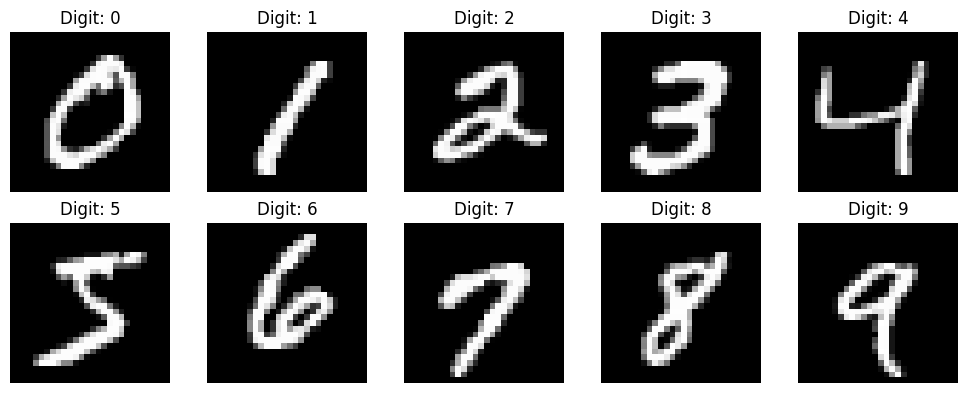

Shape check passed!


In [11]:
# STEP 1: Load the data
X_train, X_test, y_train, y_test = load_and_prepare_mnist('/content/drive/MyDrive/SEM6_AI/Week2/mnist_dataset.csv')

# STEP 2: Shape check
assert len(X_train) == len(y_train), "Shape mismatch!"
print("Shape check passed!")

#One Hot Encoding

Since the model cannot compute digits like '3' or '7' we need to convert it to binary '0' or '1'. One hot encoding does this. For eg for '3' the output would be [0,0,0,1,0,0,0,0,0,0]


***sparse_output=False*** gives us a normal numpy array instead of a compressed format.

***fit*** - learn what digits exist in the data (0 through 9)

***transform*** - actually convert the digits

***fit_transform*** - only performed on training data so the encoder learns from the training data only, not on test data cause we never let the model learn anything from the test data

In [12]:
# STEP 3: One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)
y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test  = encoder.transform(y_test.reshape(-1, 1))

print("Before encoding - shape was: (n_samples,)")
print(f"After encoding  - y_train shape: {y_train.shape}")
print(f"After encoding  - y_test shape:  {y_test.shape}")

Before encoding - shape was: (n_samples,)
After encoding  - y_train shape: (48000, 10)
After encoding  - y_test shape:  (12000, 10)


#Initialize Weights

In [13]:
# STEP 4: Initialize weights and bias
d = X_train.shape[1]  # number of features (784 pixels)
c = y_train.shape[1]  # number of classes (10 digits) cause we've one hot enconded it into 10 classes

W = np.random.randn(d, c) * 0.01  # creates a matrix of shape (784, 10) filled with tiny random numbers. Multiply by 0.01 to keep the starting values very small.
b = np.zeros(c)                    # bias starts at zero for each class in 'y'

print(f"Number of features (d): {d}")
print(f"Number of classes  (c): {c}")
print(f"Weight matrix shape: {W.shape}")
print(f"Bias vector shape:   {b.shape}")

Number of features (d): 784
Number of classes  (c): 10
Weight matrix shape: (784, 10)
Bias vector shape:   (10,)


#Training the Model

The graph plots the cost after every iteration

Iteration 0, Cost: 2.1938
Iteration 100, Cost: 0.6078
Iteration 200, Cost: 0.4899
Iteration 300, Cost: 0.4412
Iteration 400, Cost: 0.4130
Iteration 500, Cost: 0.3941
Iteration 600, Cost: 0.3803
Iteration 700, Cost: 0.3695
Iteration 800, Cost: 0.3609
Iteration 900, Cost: 0.3537


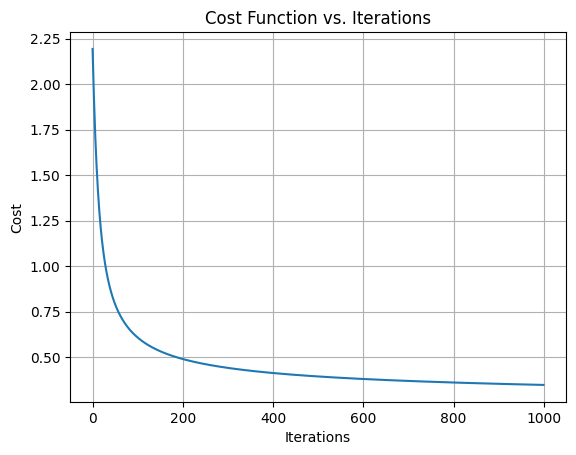

In [14]:
# STEP 5: Train the model
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha=0.1, n_iter=1000, show_cost=True #prints the cost every 100 iterations
)

# Plot the cost history
plt.plot(cost_history)
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.grid(True)
plt.show()

#Evaluate the Model

Precision: 0.90
Recall:    0.90
F1-Score:  0.90


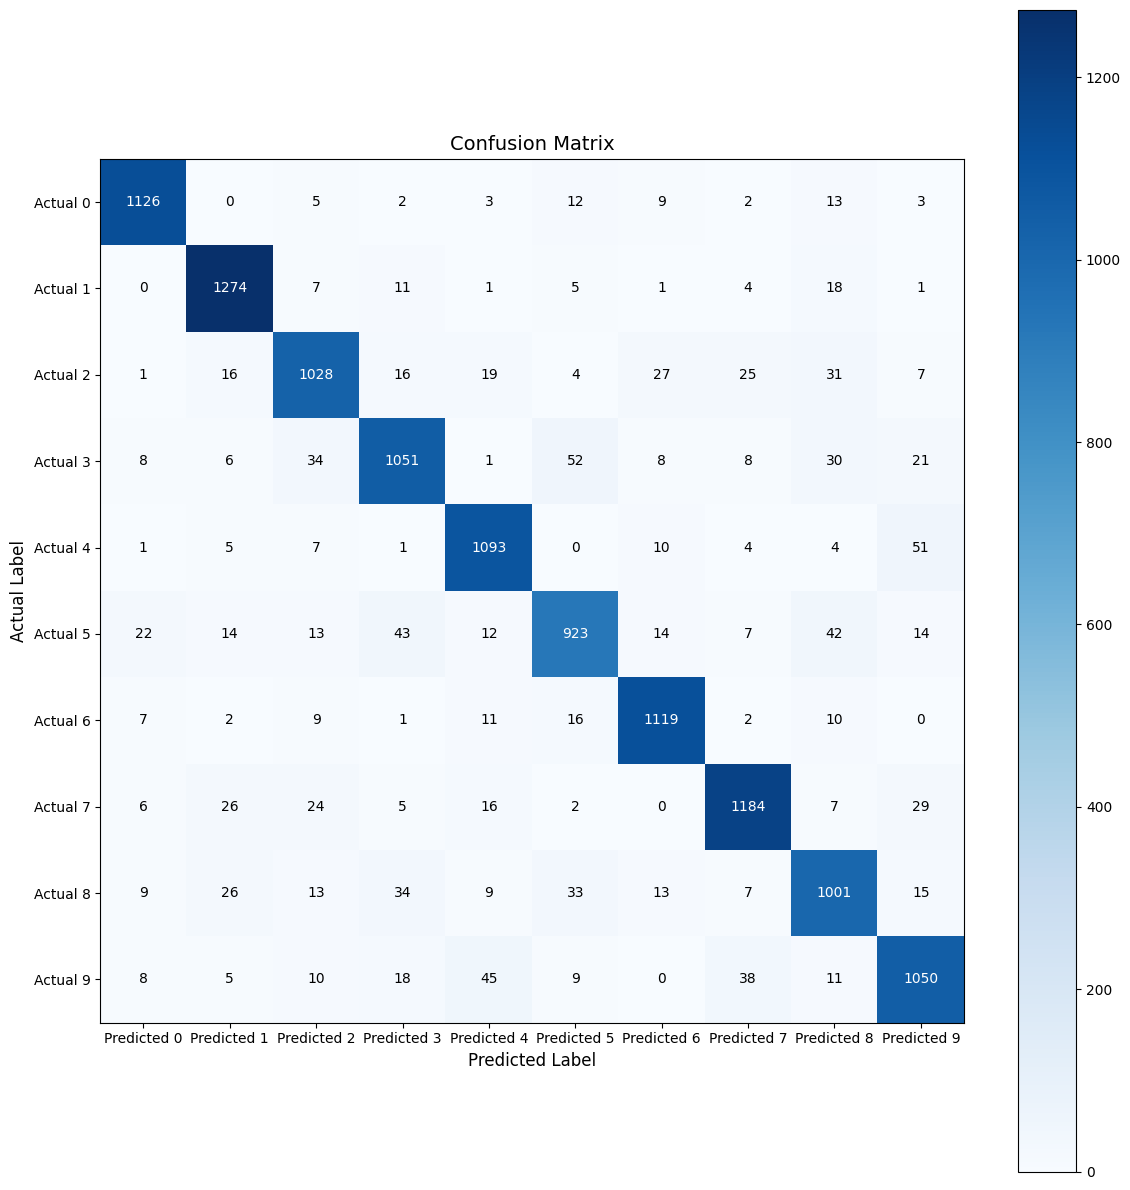

In [15]:
# STEP 6: Predict on test set
y_pred_test = predict_softmax(X_test, W_opt, b_opt)

# STEP 7: Convert one-hot encoded test labels back to numbers
y_test_labels = np.argmax(y_test, axis=1) #finds the position of  '1' and converts it back to plain number

# STEP 8: Evaluate
cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

# Print results
print(f"Precision: {precision:.2f}")
print(f"Recall:    {recall:.2f}")
print(f"F1-Score:  {f1:.2f}")

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')
num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)])
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > np.max(cm) / 2 else 'black')
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.colorbar(cax)
plt.tight_layout()
plt.show()

The diagonal (dark blue squares) are the correct predictions. Everything off the diagnols are mistakes.

# Question 1 - Is extracting pixel values sufficient for effective feature extraction? Why or why not?

Handwritten digit recognition presents an inherently complex classification problem due to the significant intra-class variability introduced by individual writing styles. Unlike structured data with well-defined features, handwritten digits lack a fixed visual template — the same digit can vary considerably in stroke width, curvature, slant, and spatial positioning across different writers. Consequently, simple linear models such as softmax regression, which rely on fixed pixel-level features, struggle to generalise effectively across this variability.


Deep learning models, particularly Convolutional Neural Networks (CNNs), are better suited for such tasks as they automatically learn hierarchical spatial representations — detecting low-level features such as edges and curves in early layers, and progressively combining them into higher-level structural patterns in deeper layers. This hierarchical feature learning enables CNNs to achieve spatial invariance, recognising digits correctly regardless of stylistic variation, resulting in substantially higher classification accuracy compared to traditional machine learning approaches.

# **Task 2**

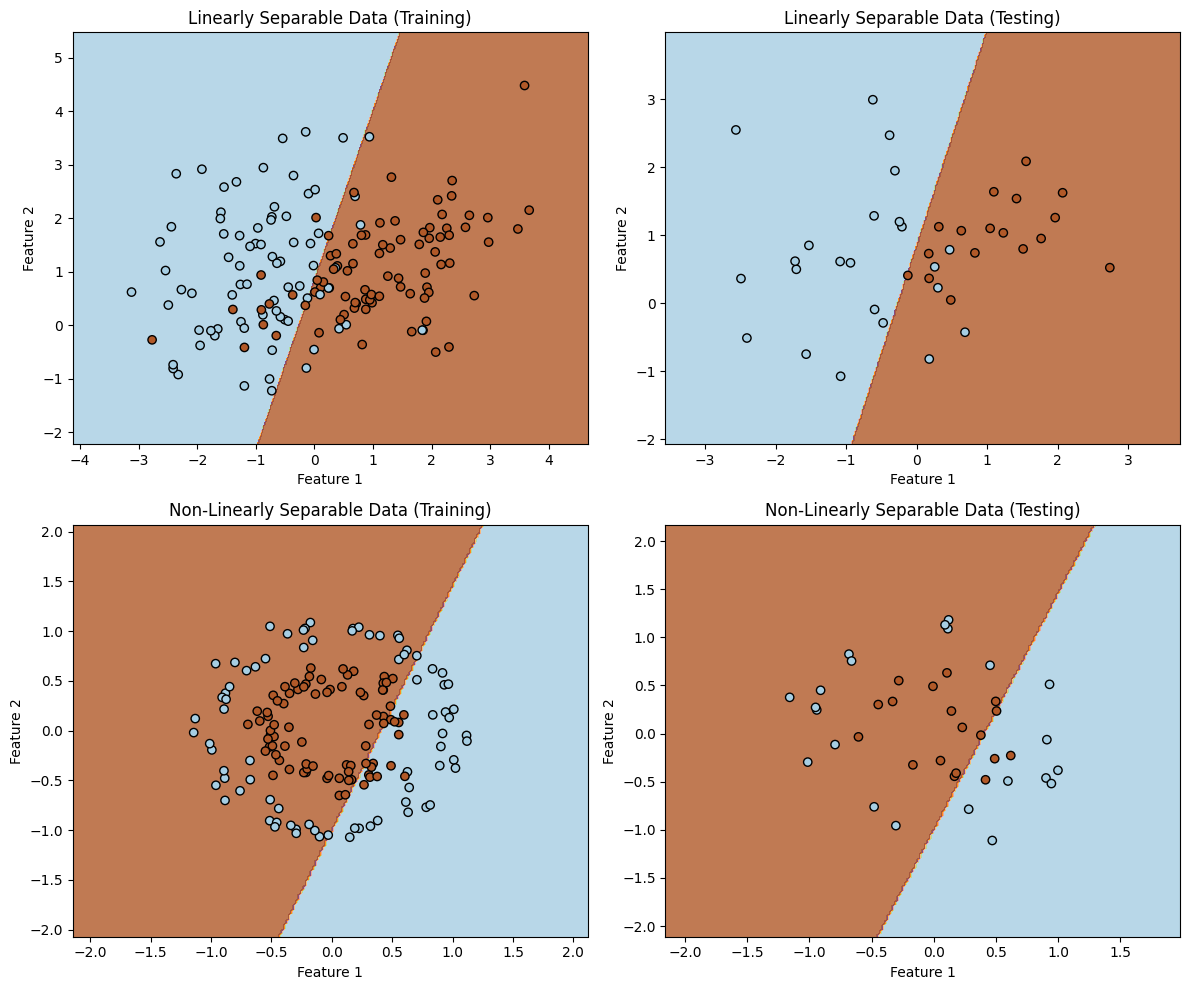

Done! Plots saved as decision_boundaries.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Set random seed for reproducibility
np.random.seed(42)

# Generate linearly separable dataset
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2,
    n_informative=2, n_redundant=0,
    n_clusters_per_class=1, random_state=42
)

# Split the data into training and testing sets
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on linearly separable data
logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# Generate non-linearly separable dataset (circles)
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

# Split the data into training and testing sets
X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

# Train logistic regression model on non-linearly separable data
logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# Plot decision boundaries for linearly and non-linearly separable data
def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot decision boundary for linearly separable data (Training)
plot_decision_boundary(
    axes[0, 0], logistic_model_linear_separable,
    X_train_linear, y_train_linear,
    'Linearly Separable Data (Training)'
)

# Plot decision boundary for linearly separable data (Testing)
plot_decision_boundary(
    axes[0, 1], logistic_model_linear_separable,
    X_test_linear, y_test_linear,
    'Linearly Separable Data (Testing)'
)

# Plot decision boundary for non-linearly separable data (Training)
plot_decision_boundary(
    axes[1, 0], logistic_model_non_linear_separable,
    X_train_non_linear, y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)

# Plot decision boundary for non-linearly separable data (Testing)
plot_decision_boundary(
    axes[1, 1], logistic_model_non_linear_separable,
    X_test_non_linear, y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()

print("Done! Plots saved as decision_boundaries.png")

# Question 2 - Provide an interpretation of the output based on your understanding.

The four plots illustrate the behaviour of logistic regression when applied to two fundamentally different data distributions — a linearly separable dataset and a non-linearly separable dataset arranged in concentric circles.

**Linearly Separable Data (Top Row)**

In the training plot (top left), the logistic regression model produces a diagonal linear decision boundary that effectively partitions the feature space into two distinct regions — blue and brown. The majority of data points are correctly classified within their respective regions, with only a small number of points falling on the incorrect side of the boundary near the decision margin. This is consistent with the expected behaviour of logistic regression on linearly separable data, as the model is capable of identifying a hyperplane that adequately separates the two classes. The testing plot (top right) exhibits a similar decision boundary with comparable classification performance, indicating that the model generalises well to unseen data without evidence of overfitting. The consistency between training and testing performance confirms that the learned boundary is robust and not merely a product of memorising the training set.

**Non-Linearly Separable Data (Bottom Row)**

In the training plot (bottom left), the logistic regression model again produces a straight diagonal decision boundary. However, this boundary is fundamentally inappropriate for the concentric circle structure of the data, where one class is entirely enclosed within the other. The linear boundary arbitrarily bisects the dataset diagonally, resulting in significant misclassification of both classes across both regions of the feature space. The testing plot (bottom right) reflects the same inadequacy, with the straight boundary failing to capture the circular geometry of the data. The misclassification is not a consequence of overfitting but rather a fundamental incompatibility between the linear decision surface of logistic regression and the non-linear structure of the dataset.

**Overall Conclusion**

These results empirically demonstrate that logistic regression is an effective classifier exclusively for linearly separable problems. When the underlying data distribution is non-linear, as in the concentric circles case, the model's inability to produce curved or complex decision boundaries renders it insufficient. For such problems, non-linear classifiers such as Support Vector Machines with radial basis function kernels, decision trees, or neural networks would be required to achieve satisfactory classification performance.



# Question 3 - Describe any challenges you faced while implementing the code above.

Although the code was provided in its entirety and did not require independent implementation, several conceptual and technical challenges were encountered during the process of understanding and executing it.

The most significant conceptual challenge involved understanding the ***plot_decision_boundary*** function. The technique of generating a fine meshgrid across the entire feature space and querying the model at every grid point to reveal the decision boundary was not immediately intuitive. Understanding that the coloured regions in the plots emerge from thousands of individual predictions rather than a directly drawn line required careful reading of the code.

A further conceptual challenge involved understanding why logistic regression fundamentally fails on the non-linearly separable dataset. It was not immediately apparent that no straight line could ever correctly separate two concentric circles regardless of its orientation or position, and that this represents a structural limitation of the model rather than a tuning or parameter issue.

Finally, a notable observation was that the logistic regression model produces no warning or error when applied to non-linearly separable data — it silently fits an inappropriate boundary, reinforcing the importance of visually inspecting decision boundaries rather than relying solely on model outputs.